## **Original GA vs Robust GA**

Testing of a new robust GA created for clasification workflow. 

This GA has demostrated better selection than the original one, reducing the number of features from

### Configuration


In [17]:
target = 'pxr'  # 'ahr', 'pxr', 'car' The file names must be {target}_ligands.csv
model_name = 'xgb'  # 'rf', 'xgb', 'svm', 'lr', 'stacking'

In [18]:
import os
from pathlib import Path
import sys

# Define xenotox as base directory
BASE_DIR = Path(f"{os.getcwd()}/..").resolve()

# Add parent directory to sys.path for imports
sys.path.append(str(BASE_DIR))

# Create output directories
os.makedirs(f"{BASE_DIR}/outputs_clf/{target}/models", exist_ok=True)
os.makedirs(f"{BASE_DIR}/outputs_clf/{target}/plots", exist_ok=True)
os.makedirs(f"{BASE_DIR}/outputs_clf/{target}/reports", exist_ok=True)

### Curation

In [19]:
import pandas as pd
from utils_clf.curation import curate_data

# Load data
df = pd.read_csv(f"{BASE_DIR}/ligands/{target}/{target}_ligands.csv")

# Curate data
df_curated = curate_data(df,"SMILES", "Agonist_Activity")
display(df_curated.head())

Curation completed: 6258 valid molecules (out of 6260 initial).


,Agonist_Activity,SMILES
0,inactive,BrC(Br)Br
1,inactive,BrC(Br)C(Br)(Br)Br
2,inactive,BrC(Br)C(Br)Br
3,inactive,BrC/C=C/CBr
4,active,BrC1CCC(Br)C(Br)CCC(Br)C(Br)CCC1Br


### Descriptors


In [20]:
from utils_clf.descriptors import descriptor_matrix

# Generate X and y
X, y = descriptor_matrix(df_curated, "SMILES", "Agonist_Activity")

# Full descriptor list for saving model components
full_descriptor_list = X.columns.tolist()

print(f"Descriptor matrix shape: {X.shape}")

Initializing calculation with 2 cores...


RDKit progress: 100%|██████████| 6258/6258 [01:48<00:00, 57.91it/s] 


Descriptor matrix shape: (6230, 217)


### Data split and encoding

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    stratify=y,
    test_size=0.3,
    random_state=42
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 4361 | Test: 1869


In [22]:
y_train_enc = y_train.map({"inactive": 0, "active": 1})
y_test_enc = y_test.map({"inactive": 0, "active": 1})

count_train = pd.Series(y_train_enc).value_counts()
count_test = pd.Series(y_test_enc).value_counts()

print(f"Train distribution: Active(1) = {count_train[1]}, Inactive(0) = {count_train[0]}")
print(f"Test distribution: Active(1) = {count_test[1]}, Inactive(0) = {count_test[0]}")

Train distribution: Active(1) = 1144, Inactive(0) = 3217
Test distribution: Active(1) = 490, Inactive(0) = 1379


### Feature filtering


In [23]:
from utils_clf.filtering import filter_features

X_train_filtered, X_test_filtered = filter_features(X_train, X_test)

Variance Filter (threshold 0.01)
Deleted features by variance: 24
Features after variance: 193

Correlation Filter (threshold 0.9)
Deleted features by correlation: 43
Final features post-filtering: 150


### Genetic Algorithm

In [24]:
# Extract filtered feature names for ga
filtered_features = X_train_filtered.columns.tolist()

In [ ]:
# ORIGINAL GA CODE

from utils_clf.ga import ga_feature_selection

# Extract filtered feature names for ga
filtered_features = X_train_filtered.columns.tolist()

# Run GA
selected_features = ga_feature_selection(X_train_filtered, y_train_enc, filtered_features)

c:\Users\elias\miniconda3\envs\qsar_classif_env\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
c:\Users\elias\miniconda3\envs\qsar_classif_env\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


gen	nevals	avg      	max     	min      
0  	50    	0.0425546	0.344102	-0.286667
1  	41    	0.254288 	0.345674	-0.26    
2  	47    	0.318838 	0.342927	0.275505 
3  	40    	0.317739 	0.358767	-0.246667
4  	44    	0.338013 	0.36051 	0.303296 
5  	33    	0.345902 	0.362238	0.314206 
6  	38    	0.350739 	0.363591	0.328794 
7  	42    	0.352783 	0.371146	0.323322 
8  	36    	0.358258 	0.375833	0.321748 
9  	44    	0.350978 	0.385499	-0.203333
10 	39    	0.368044 	0.389775	0.345295 
11 	36    	0.362957 	0.390788	-0.18    
12 	34    	0.378488 	0.390728	0.36127  
13 	42    	0.372341 	0.391339	-0.176667
14 	38    	0.386886 	0.395875	0.372109 
15 	38    	0.378587 	0.395877	-0.173333
16 	34    	0.392118 	0.400656	0.376975 
17 	39    	0.382772 	0.404758	-0.153333
18 	39    	0.396804 	0.404758	0.375048 
19 	43    	0.399061 	0.404758	0.389219 
20 	40    	0.400876 	0.406357	0.38811  
21 	43    	0.402985 	0.408135	0.387463 
22 	41    	0.403085 	0.40934 	0.387014 
23 	42    	0.4053   	0.412674	0.394737 


In [25]:
# ROBUST GA CODE

from utils_clf.robust_ga import ga_feature_selection

robust_selected_features, best_fitness, hof, log = ga_feature_selection(X_train_filtered, y_train_enc, 
                                                                        filtered_features, n_gen=30, pop_size=50)

gen	nevals	avg    	max     	min     	std    
0  	50    	-4.1895	0.424012	-20.8995	5.33168
1  	100   	-0.507986	0.396156	-7.2064 	1.16739
2  	100   	0.0550036	0.396156	-1      	0.51219
3  	100   	0.326544 	0.429201	-0.471131	0.137934
4  	100   	0.377017 	0.43304 	0.304933 	0.0285228
5  	100   	0.402866 	0.435521	0.360678 	0.0182871
6  	100   	0.410637 	0.435521	0.381874 	0.0140742
7  	100   	0.416576 	0.435521	0.383548 	0.0126574
8  	100   	0.423525 	0.440209	0.395292 	0.0097895
9  	100   	0.431222 	0.4499  	0.407061 	0.00660019
10 	100   	0.435818 	0.4499  	0.427576 	0.00446854
11 	100   	0.438704 	0.461595	0.426255 	0.00637673
12 	100   	0.442166 	0.461595	0.426255 	0.00599368
13 	100   	0.44581  	0.461595	0.42915  	0.00667404
14 	100   	0.448701 	0.461595	0.438943 	0.00520463
15 	100   	0.453171 	0.461959	0.444799 	0.00384824
16 	100   	0.455022 	0.464136	0.448949 	0.00363141
17 	100   	0.457185 	0.464136	0.449743 	0.00314601
18 	100   	0.459422 	0.464584	0.453815 	0.00275417
19 	100

In [26]:
print(f"\n Selected features: {len(robust_selected_features)}")
print(" Descriptors:")
for i, f in enumerate(robust_selected_features, 1):
    print(f"{i:2d}. {f}")


 Selected features: 10
 Descriptors:
 1. BCUT2D_CHGLO
 2. Kappa3
 3. PEOE_VSA9
 4. SMR_VSA6
 5. VSA_EState5
 6. NHOHCount
 7. NumAliphaticCarbocycles
 8. NumHeteroatoms
 9. MolLogP
10. fr_COO


### Preprocessing with robust GA selected features

In [27]:
from utils_clf.preprocessor import build_preprocessor
# Process filtered and selected features for training and testing
preprocessor = build_preprocessor()
X_train_proc = preprocessor.fit_transform(X_train_filtered[robust_selected_features])
X_test_proc = preprocessor.transform(X_test_filtered[robust_selected_features])

### Training with optimization

In [28]:
from utils_clf.optimization import optimize_model, save_model
from utils_clf.optimization import train_stacking_model

if model_name == "stacking":
    final_model = train_stacking_model(X_train_proc, y_train_enc)
    #save_model(BASE_DIR, target, model_name, final_model,
     #       full_descriptor_list, selected_features, preprocessor)
    
else:
    final_model = optimize_model(X_train_proc, y_train_enc, model_name)
    #save_model(BASE_DIR, target, model_name, final_model, 
     #       full_descriptor_list, selected_features, preprocessor)

[I 2026-04-03 22:07:47,885] A new study created in memory with name: xgb_study
[I 2026-04-03 22:07:53,864] Trial 0 finished with value: 0.5520779149818069 and parameters: {'n_estimators': 487, 'max_depth': 5, 'learning_rate': 0.08960785365368121, 'subsample': 0.779597545259111, 'colsample_bytree': 0.6468055921327309, 'gamma': 0.04679835610086079, 'min_child_weight': 1, 'reg_alpha': 0.21423021757741043, 'reg_lambda': 0.2537815508265665}. Best is trial 0 with value: 0.5520779149818069.
[I 2026-04-03 22:07:59,926] Trial 1 finished with value: 0.5279285202817606 and parameters: {'n_estimators': 654, 'max_depth': 3, 'learning_rate': 0.18276027831785724, 'subsample': 0.8497327922401265, 'colsample_bytree': 0.6637017332034828, 'gamma': 0.05454749016213018, 'min_child_weight': 2, 'reg_alpha': 0.00033205591037519585, 'reg_lambda': 0.12561043700013558}. Best is trial 0 with value: 0.5520779149818069.
[I 2026-04-03 22:08:04,120] Trial 2 finished with value: 0.5672282426743009 and parameters: {'n_

### Internal validation

  Model Target  Threshold  Accuracy  Bal_Accuracy  Precision    Recall  \
0   xgb    pxr        0.5  0.811129      0.802937   0.608215  0.785714   

   Specificity  F1_score   ROC_AUC    PR_AUC       MCC  
0      0.82016  0.685663  0.865179  0.663018  0.563056  


c:\Users\elias\miniconda3\envs\qsar_classif_env\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


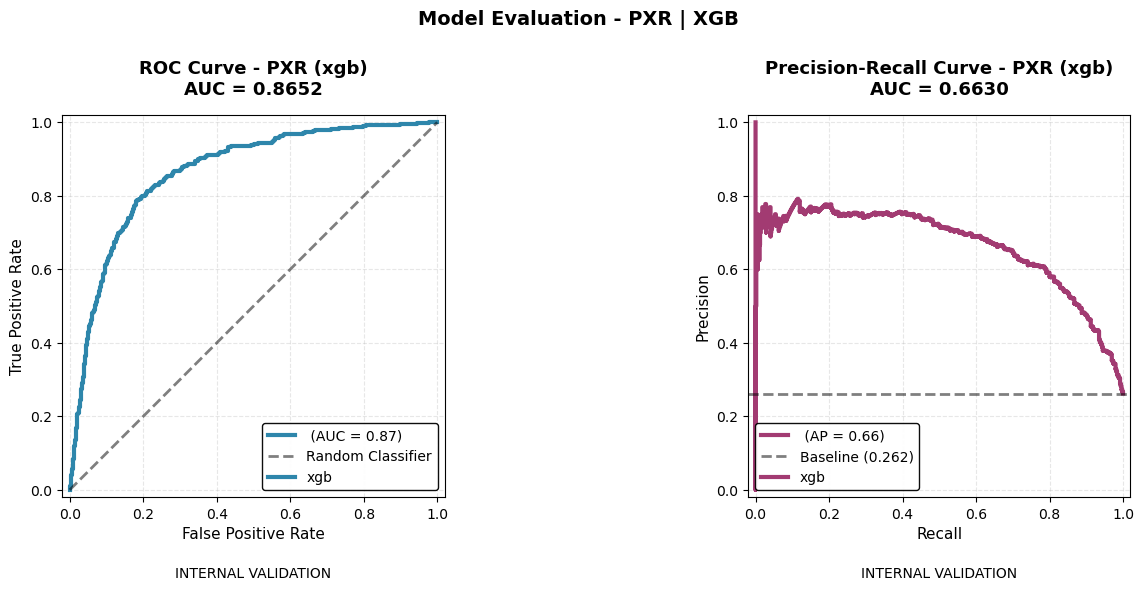

C:\Users\elias\AppData\Local\Temp\ipykernel_9076\2222487492.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot.show()


In [29]:
from utils_clf.validation import compute_metrics
plot, metrics = compute_metrics(final_model, X_test_proc, y_test_enc, model_name, target)
plot.show()

#Save metrics and plot
#metrics.to_csv(f"{BASE_DIR}/outputs_clf/{target}/reports/internal_validation_{target}_{model_name}.csv", index=False)
#plot.savefig(f"{BASE_DIR}/outputs_clf/{target}/plots/internal_roc_pr_{target}_{model_name}.png", dpi=300)

### Applicability Domain (AD)


Training set size: 4361
Number of descriptors: 10
AD threshold (h*): 0.0076
Compounds outside AD: 2.8% (53/1869)
Leverage range - Train: [0.0000, 0.3341]
Leverage range - Test:  [0.0001, 0.1754]


C:\Users\elias\AppData\Local\Temp\ipykernel_9076\3377292891.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot.show()


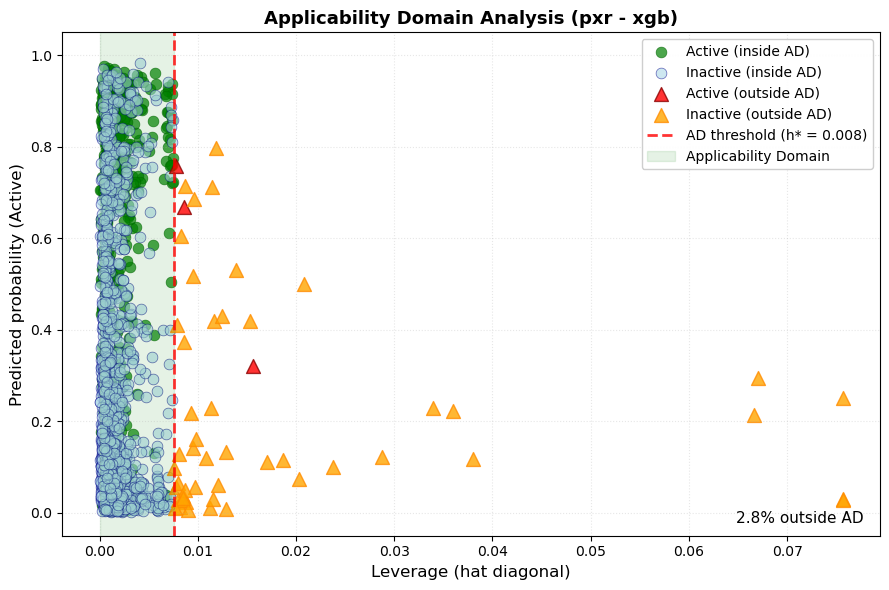

In [30]:
from utils_clf.applicability_domain import applicability_domain_analysis as ad
y_proba = metrics["y_proba"]
plot = ad(target, model_name, X_train_proc, X_test_proc, y_test_enc, y_proba)
plot.show()
# Save plot
#plot.savefig(f"{BASE_DIR}/outputs_clf/{target}/plots/ad_{target}_{model_name}.png", dpi=300, bbox_inches="tight")

### External Validation

Curation completed: 306 valid molecules (out of 306 initial).
Initializing calculation with 2 cores...


RDKit progress: 100%|██████████| 306/306 [00:08<00:00, 37.19it/s]


  Model Target  Threshold  Accuracy  Bal_Accuracy  Precision    Recall  \
0   xgb    pxr        0.5  0.869159      0.878107   0.791304  0.957895   

   Specificity  F1_score   ROC_AUC   PR_AUC       MCC  
0     0.798319  0.866667  0.950995  0.93353  0.753553  


c:\Users\elias\miniconda3\envs\qsar_classif_env\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


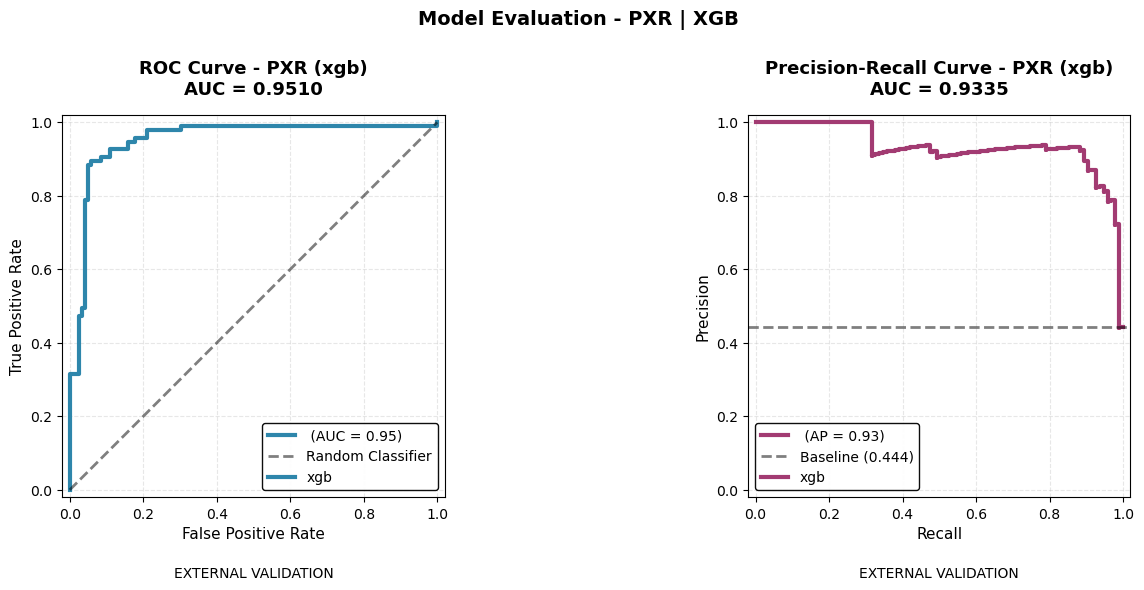

In [31]:
# Load external dataset
df_ext = pd.read_csv(f"{BASE_DIR}/ext_ligands/{target}/ext_{target}_ligands.csv")
# Curation
df_ext_curated = curate_data(df_ext,"SMILES", "Agonist_Activity")
# Descriptor calculation
X_ext, y_ext = descriptor_matrix(df_ext_curated, "SMILES", "Agonist_Activity")
# Split and encode labels
X_ext_train, X_ext_test, y_ext_train, y_ext_test = train_test_split(
    X_ext, y_ext,
    stratify=y_ext,
    test_size=0.3,
    random_state=42
)
y_ext_train_enc = y_ext_train.map({"inactive": 0, "active": 1})
# Apply selected features to train set
X_ext_filtered = X_ext_train[robust_selected_features]
# Preprocess
X_ext_proc = preprocessor.transform(X_ext_filtered)
# Evaluation
plot_ext, metrics_ext = compute_metrics(final_model, X_ext_proc, y_ext_train_enc, model_name, target, data_type="external")

# Save metrics and plot
#metrics_ext.to_csv(
#    f"{BASE_DIR}/outputs_clf/{target}/reports/external_validation_{target}_{model_name}.csv", index=False)
#plot_ext.savefig(
#    f"{BASE_DIR}/outputs_clf/{target}/plots/external_roc_pr_{target}_{model_name}.png", dpi=300)

Training set size: 4361
Number of descriptors: 10
AD threshold (h*): 0.0076
Compounds outside AD: 14.5% (31/214)
Leverage range - Train: [0.0000, 0.3341]
Leverage range - Test:  [0.0002, 0.0290]


C:\Users\elias\AppData\Local\Temp\ipykernel_9076\1695783465.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  ext_ad.show()


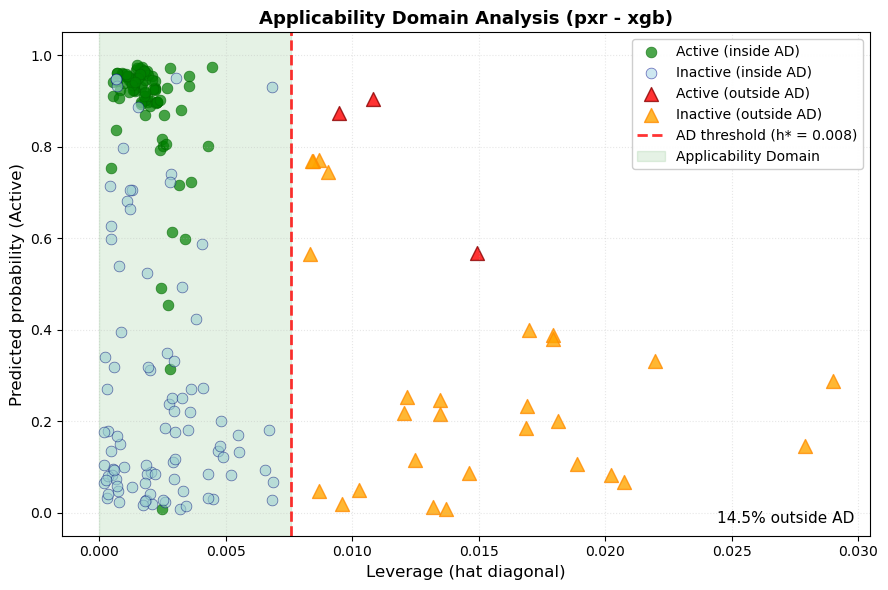

In [33]:
# Applicability domain analysis for external set
y_ext_proba = metrics_ext["y_proba"]
ext_ad = ad(target, model_name, X_train_proc, X_ext_proc, y_ext_train_enc, y_ext_proba)
ext_ad.show()
